# bytetoken — BPE from scratch

Byte-pair encoding with a GPT-4/cl100k-style regex pre-tokenization pass.

In [1]:
import os, sys
import matplotlib.pyplot as plt
from bpe import BPETokenizer
from pretokenize import pre_tokenize

## Load training data

In [2]:
with open('data/input.txt') as f:
    text = f.read()
print(f'{len(text):,} characters')
print(text[:200])

1,115,394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## Pre-tokenization

Before BPE, we split text with a pattern adapted from minbpe's `GPT4_SPLIT_PATTERN`. It separates letter, number, punctuation, and whitespace regions before this project learns its own merges.

In [3]:
sample = "ROMEO:\nO, she doth teach the torches to burn bright!"
chunks = pre_tokenize(sample)
print(f'Input: {repr(sample)}\n')
print(f'{len(chunks)} chunks:')
for c in chunks:
    print(f'  {repr(c)}')

Input: 'ROMEO:\nO, she doth teach the torches to burn bright!'

13 chunks:
  'ROMEO'
  ':\n'
  'O'
  ','
  ' she'
  ' doth'
  ' teach'
  ' the'
  ' torches'
  ' to'
  ' burn'
  ' bright'
  '!'


## Train and inspect merges

What does BPE learn first? The most frequent byte pairs — spaces, common bigrams like `th`, `he`, `in`.

In [4]:
tok = BPETokenizer()
tok.train(text, vocab_size=500, verbose=True)

merge 50/244: (111, 109) -> 305 ('om')


merge 100/244: (69, 78) -> 355 ('EN')


merge 150/244: (84, 111) -> 405 ('To')


merge 200/244: (306, 381) -> 455 (' good')


trained 244 merges, vocab size: 500


In [5]:
# first 30 merges — these are the most frequent byte pairs in shakespeare
print('First 30 merges learned:')
print(f'{"merge":>6}  {"pair":>12}  {"result":>10}')
print('-' * 32)
for i, ((a, b), new_id) in enumerate(tok.merges.items()):
    if i >= 30:
        break
    a_str = tok.vocab[a].decode('utf-8', errors='replace')
    b_str = tok.vocab[b].decode('utf-8', errors='replace')
    merged = tok.vocab[new_id].decode('utf-8', errors='replace')
    print(f'{i+1:>6}  {repr(a_str)+"+"+repr(b_str):>12}  {repr(merged):>10}')

First 30 merges learned:
 merge          pair      result
--------------------------------
     1       ' '+'t'        ' t'
     2       'h'+'e'        'he'
     3       ' '+'a'        ' a'
     4       'o'+'u'        'ou'
     5       ' '+'s'        ' s'
     6       ' '+'m'        ' m'
     7       'i'+'n'        'in'
     8       ' '+'w'        ' w'
     9       'r'+'e'        're'
    10       'h'+'a'        'ha'
    11      ':'+'\n'       ':\n'
    12       'n'+'d'        'nd'
    13     ' t'+'he'      ' the'
    14       ' '+'b'        ' b'
    15       'i'+'s'        'is'
    16       'o'+'r'        'or'
    17     '\n'+'\n'      '\n\n'
    18       ' '+'f'        ' f'
    19       'e'+'r'        'er'
    20       'l'+'l'        'll'
    21       'i'+'t'        'it'
    22       'o'+'n'        'on'
    23      ','+'\n'       ',\n'
    24       ' '+'d'        ' d'
    25       ' '+'c'        ' c'
    26       'e'+'s'        'es'
    27       'e'+'n'        'en'
    28       ' '+'

## Tokenize a passage

Show token boundaries in a sample.

In [6]:
sample = """ROMEO:
O, she doth teach the torches to burn bright!
It seems she hangs upon the cheek of night
Like a rich jewel in an Ethiope's ear;"""

tokens = tok.encode(sample)
print(f'{len(sample)} chars -> {len(tokens)} tokens ({len(sample)/len(tokens):.1f} chars/token)\n')

# show each token
for t in tokens:
    s = tok.vocab[t].decode('utf-8', errors='replace')
    print(f'  [{t:>3}] {repr(s)}')

134 chars -> 75 tokens (1.8 chars/token)

  [ 82] 'R'
  [ 79] 'O'
  [ 77] 'M'
  [ 69] 'E'
  [ 79] 'O'
  [266] ':\n'
  [ 79] 'O'
  [ 44] ','
  [490] ' she'
  [279] ' d'
  [298] 'ot'
  [104] 'h'
  [256] ' t'
  [389] 'ea'
  [326] 'ch'
  [268] ' the'
  [256] ' t'
  [271] 'or'
  [ 99] 'c'
  [257] 'he'
  [115] 's'
  [291] ' to'
  [269] ' b'
  [368] 'ur'
  [110] 'n'
  [269] ' b'
  [347] 'ri'
  [354] 'ght'
  [444] '!\n'
  [ 73] 'I'
  [116] 't'
  [399] ' se'
  [491] 'em'
  [115] 's'
  [490] ' she'
  [313] ' ha'
  [110] 'n'
  [103] 'g'
  [115] 's'
  [450] ' up'
  [277] 'on'
  [268] ' the'
  [280] ' c'
  [257] 'he'
  [101] 'e'
  [107] 'k'
  [304] ' of'
  [283] ' n'
  [442] 'ight'
  [ 10] '\n'
  [ 76] 'L'
  [105] 'i'
  [332] 'ke'
  [258] ' a'
  [ 32] ' '
  [347] 'ri'
  [326] 'ch'
  [ 32] ' '
  [106] 'j'
  [101] 'e'
  [119] 'w'
  [101] 'e'
  [108] 'l'
  [311] ' in'
  [410] ' an'
  [473] ' E'
  [116] 't'
  [379] 'hi'
  [111] 'o'
  [112] 'p'
  [101] 'e'
  [324] "'s"
  [338] ' e'
  [288] 'ar'
  [ 59] 

## Compression vs vocab size

Bigger vocab = fewer tokens to represent the same text. The tradeoff: larger embedding tables.

In [7]:
vocab_sizes = [256, 300, 500, 1000, 2000]
raw_bytes = len(text.encode('utf-8'))
results = []

for vs in vocab_sizes:
    if vs == 256:
        # no merges — just raw bytes
        n_tokens = raw_bytes
    else:
        t = BPETokenizer()
        t.train(text, vocab_size=vs)
        n_tokens = len(t.encode(text))
    ratio = raw_bytes / n_tokens
    results.append((vs, n_tokens, ratio))
    print(f'vocab={vs:>5}: {n_tokens:>8,} tokens, {ratio:.2f}x compression')

vocab=  256: 1,115,394 tokens, 1.00x compression


vocab=  300:  791,019 tokens, 1.41x compression


vocab=  500:  553,176 tokens, 2.02x compression


vocab= 1000:  431,132 tokens, 2.59x compression


vocab= 2000:  357,642 tokens, 3.12x compression


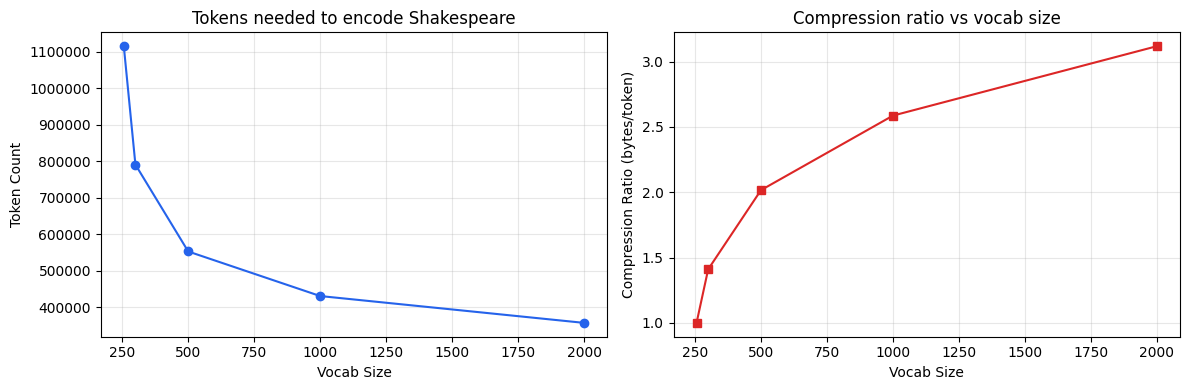

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

vs_list = [r[0] for r in results]
tokens_list = [r[1] for r in results]
ratio_list = [r[2] for r in results]

ax1.plot(vs_list, tokens_list, 'o-', color='#2563eb')
ax1.set_xlabel('Vocab Size')
ax1.set_ylabel('Token Count')
ax1.set_title('Tokens needed to encode Shakespeare')
ax1.ticklabel_format(style='plain', axis='y')

ax2.plot(vs_list, ratio_list, 's-', color='#dc2626')
ax2.set_xlabel('Vocab Size')
ax2.set_ylabel('Compression Ratio (bytes/token)')
ax2.set_title('Compression ratio vs vocab size')

for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('compression.png', dpi=150, bbox_inches='tight')
plt.show()

## Reference comparison: tiktoken GPT-2

This compares complete tokenizer outputs on the same strings. It is not a parity test: the split patterns, vocabulary sizes, merge inventories, and training corpora differ.

In [9]:
import tiktoken

enc = tiktoken.get_encoding('gpt2')

test_strings = [
    "Hello, world!",
    "The quick brown fox jumps over the lazy dog.",
    "Don't you think it's a beautiful day?",
    "ROMEO:\nO, she doth teach the torches to burn bright!",
]

print(f'{"text":>50}  {"ours":>5}  {"gpt2":>5}')
print('-' * 65)
for s in test_strings:
    ours = len(tok.encode(s))
    theirs = len(enc.encode(s))
    label = s[:47] + '...' if len(s) > 47 else s
    print(f'{label:>50}  {ours:>5}  {theirs:>5}')

                                              text   ours   gpt2
-----------------------------------------------------------------
                                     Hello, world!      8      4
      The quick brown fox jumps over the lazy dog.     27     10
             Don't you think it's a beautiful day?     19     10
ROMEO:
O, she doth teach the torches to burn br...     29     16
